# Customer Churn Prediction & Customer Segmentation

## 02 — EDA & Business Analysis

### Purpose

Data validation told us whether the raw dataset is structurally usable.

Now we move to **Exploratory Data Analysis (EDA)**.

The goal of this notebook is not to create as many charts as possible. The goal is to understand **why customers may churn** and identify patterns that can guide:

- feature engineering
- model development
- customer segmentation
- retention strategy

### Business questions

We will investigate:

1. What does the customer base look like?
2. How common is churn?
3. Does customer tenure relate to churn?
4. Does contract type relate to churn?
5. Do monthly charges differ between churned and retained customers?
6. Which customer services show meaningful churn differences?
7. Does payment method show a meaningful relationship with churn?
8. Do customer demographics show strong churn differences?
9. Which findings are useful enough to carry into feature engineering?

## 1. Import libraries

We use Pandas for analysis and Matplotlib/Seaborn for visual exploration.

The modelling libraries are intentionally not used here because this notebook is about understanding the data, not training a model.

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load the raw dataset

We load the raw CSV again so this notebook can be run independently.

The raw data remains unchanged during EDA.

In [2]:
PROJECT_ROOT = Path.cwd().parent

DATA_PATH = PROJECT_ROOT / "data" / "raw" / "Customer-Churn.csv"

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found at: {DATA_PATH}"
    )

df = pd.read_csv(DATA_PATH)

print(f"Dataset loaded successfully: {df.shape[0]:,} rows, {df.shape[1]} columns.")

Dataset loaded successfully: 7,043 rows, 21 columns.


## 3. Prepare a few display settings

These settings make tables and charts easier to read.

They do not change the underlying data.

In [3]:
pd.set_option("display.max_columns", None)

sns.set_theme(
    style="whitegrid",
    context="notebook"
)

# Part A — Understand the customer base

Before investigating churn, we need to understand who is actually present in the dataset.

## 4. Customer base overview

Let's look at the basic numerical characteristics of the customer base.

We are especially interested in:

- tenure
- monthly charges
- total charges

These variables describe customer relationship length and spending.

In [4]:
df[["tenure", "MonthlyCharges"]].describe().T

,count,mean,std,min,25%,50%,75%,max
tenure,7043.0,32.371149,24.559481,0.00,9.0,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75


### Total charges

`TotalCharges` is still stored as text in the raw dataset.

For EDA, we need a numeric representation so that we can examine its distribution.

We will create a **temporary analysis column** rather than changing the raw column.

In [5]:
df["TotalCharges_numeric"] = pd.to_numeric(
    df["TotalCharges"].astype(str).str.strip(),
    errors="coerce"
)

print("Temporary numeric TotalCharges column created for EDA.")

Temporary numeric TotalCharges column created for EDA.


### Check the conversion

Before using the temporary column, we confirm how many values could not be converted.

In [6]:
total_charges_missing = df["TotalCharges_numeric"].isnull().sum()

print(
    f"TotalCharges values unavailable for numeric analysis: "
    f"{total_charges_missing:,}"
)

TotalCharges values unavailable for numeric analysis: 11


We will not silently impute these values in EDA. Any actual cleaning decision will be documented in the Data Cleaning stage.

## 5. Churn distribution

Our first business question is simple:

> **How large is the churn problem?**

This gives us the baseline against which all later patterns should be interpreted.

In [7]:
churn_counts = df["Churn"].value_counts()

print("Number of customers by churn status:")
display(churn_counts.to_frame(name="Customers"))

Number of customers by churn status:


,Customers
Churn,
No,5174
Yes,1869


In [8]:
churn_percentages = (
    df["Churn"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("Percentage of customers by churn status:")
display(churn_percentages.to_frame(name="Percentage"))

Percentage of customers by churn status:


,Percentage
Churn,
No,73.46
Yes,26.54


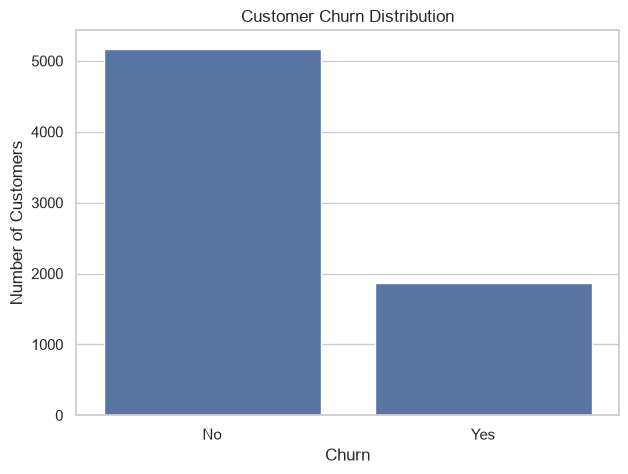

In [9]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Churn"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

### Business interpretation

The dataset contains a clear majority of customers who have not churned, while a smaller but substantial group has churned.

This matters because our future model should focus on **identifying churners effectively**, rather than simply maximizing overall accuracy.

# Part B — Customer characteristics and churn

Now we move from "what does the customer base look like?" to:

> **Which customer characteristics are associated with higher churn?**

For categorical variables, we will use **churn rate** rather than only raw customer counts.

Why?

Suppose one group contains 5,000 customers and another contains 500. Comparing the number of churners alone can be misleading.

Churn rate answers:

> Out of the customers in this group, what percentage churned?

## 6. Tenure and churn

### Business question

> Are newer customers more likely to churn than long-term customers?

Tenure is particularly important because it represents the length of the customer relationship.

In [10]:
tenure_summary = (
    df.groupby("Churn")["tenure"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
)

tenure_summary

,count,mean,median,min,max
Churn,,,,,
No,5174,37.57,38.0,0,72
Yes,1869,17.98,10.0,1,72


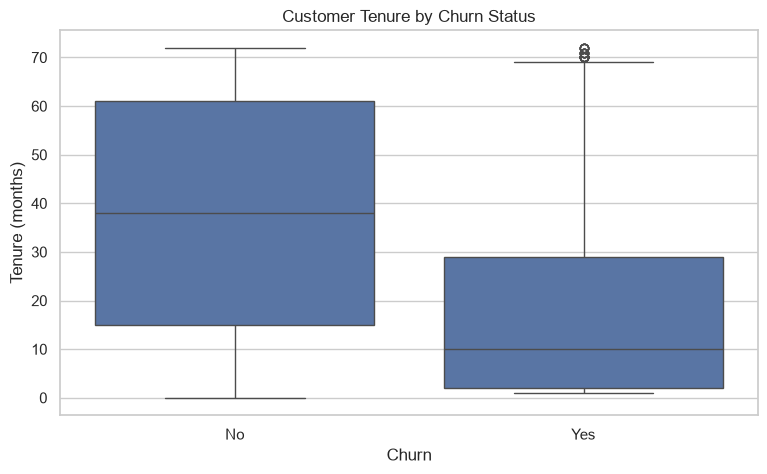

In [11]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="tenure"
)

plt.title("Customer Tenure by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Tenure (months)")

plt.show()

### Tenure bands

A single average does not always tell the whole story.

We therefore create business-friendly tenure groups to see whether churn behaviour changes across the customer lifecycle.

In [12]:
tenure_bins = [-1, 6, 12, 24, 48, float("inf")]

tenure_labels = [
    "0-6 months",
    "7-12 months",
    "13-24 months",
    "25-48 months",
    "49+ months"
]

df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=tenure_bins,
    labels=tenure_labels
)

In [13]:
tenure_churn_rate = (
    df.groupby("TenureGroup", observed=False)["Churn"]
    .apply(lambda values: (values == "Yes").mean() * 100)
    .round(2)
    .to_frame("Churn_Rate")
)

tenure_churn_rate

,Churn_Rate
TenureGroup,
0-6 months,52.94
7-12 months,35.89
13-24 months,28.71
25-48 months,20.39
49+ months,9.51


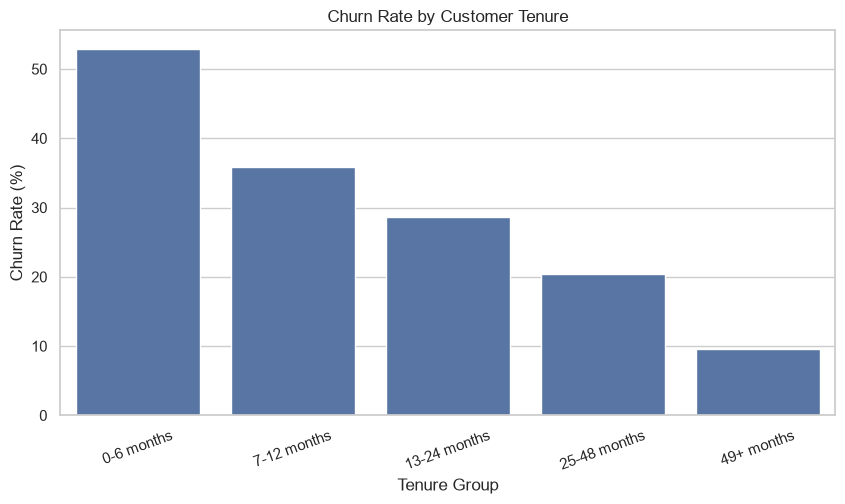

In [14]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=tenure_churn_rate.reset_index(),
    x="TenureGroup",
    y="Churn_Rate"
)

plt.title("Churn Rate by Customer Tenure")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=20)

plt.show()

### Finding

If churn is concentrated among customers with shorter tenure, this suggests that the **early customer lifecycle** may be a high-risk period.

This could later influence feature engineering and retention strategy.

We will not claim causation from this chart. It shows an association that the model and business analysis can investigate further.

## 7. Contract type and churn

### Business question

> Are customers on shorter-term contracts more likely to churn?

Contract type is directly related to the customer's commitment to the company, so this is an important business variable to investigate.

In [15]:
contract_summary = (
    df.groupby("Contract")["Churn"]
    .agg(
        Customers="count",
        Churned=lambda values: (values == "Yes").sum()
    )
)

contract_summary["Churn_Rate"] = (
    contract_summary["Churned"]
    / contract_summary["Customers"]
    * 100
).round(2)

contract_summary.sort_values(
    "Churn_Rate",
    ascending=False
)

,Customers,Churned,Churn_Rate
Contract,,,
Month-to-month,3875,1655,42.71
One year,1473,166,11.27
Two year,1695,48,2.83


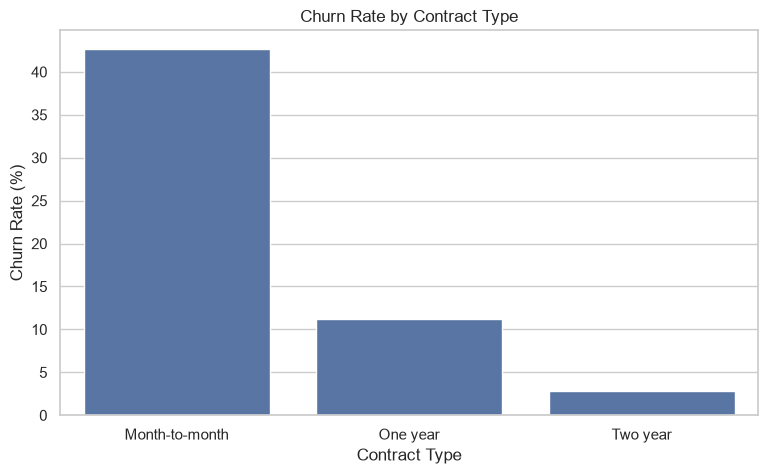

In [16]:
contract_plot_data = contract_summary.reset_index()

plt.figure(figsize=(9, 5))

sns.barplot(
    data=contract_plot_data,
    x="Contract",
    y="Churn_Rate"
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")

plt.show()

### Business interpretation

A large difference in churn rate between contract types would be an important business signal.

For example, if month-to-month customers show substantially higher churn, retention efforts may need to focus on:

- early engagement
- contract conversion
- targeted offers
- service issues affecting short-term customers

These are business hypotheses, not conclusions of causality.

## 8. Monthly charges and churn

### Business question

> Are customers paying higher monthly charges more likely to churn?

Monthly charges may capture the customer's current financial commitment to the service.

In [17]:
monthly_charges_summary = (
    df.groupby("Churn")["MonthlyCharges"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
)

monthly_charges_summary

,count,mean,median,min,max
Churn,,,,,
No,5174,61.27,64.43,18.25,118.75
Yes,1869,74.44,79.65,18.85,118.35


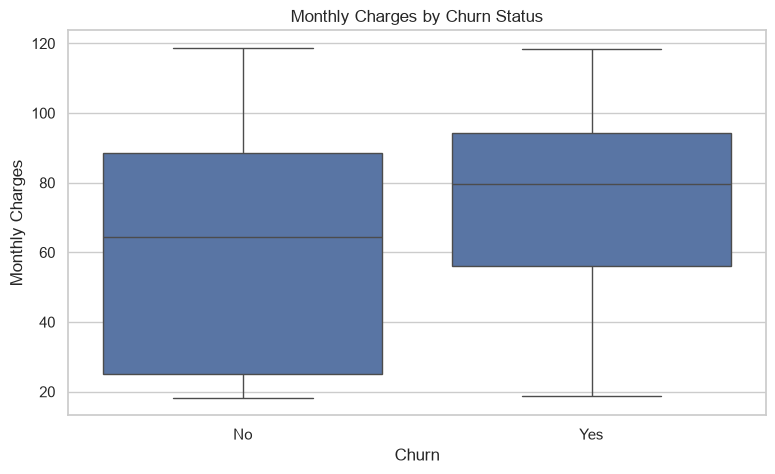

In [18]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

### Additional view: charge bands

To make the relationship easier to interpret from a business perspective, we can divide monthly charges into broad bands.

In [19]:
monthly_charge_bins = [0, 30, 60, 90, 120, float("inf")]

monthly_charge_labels = [
    "≤ 30",
    "31-60",
    "61-90",
    "91-120",
    "120+"
]

df["MonthlyChargeGroup"] = pd.cut(
    df["MonthlyCharges"],
    bins=monthly_charge_bins,
    labels=monthly_charge_labels
)

In [20]:
monthly_charge_churn_rate = (
    df.groupby("MonthlyChargeGroup", observed=False)["Churn"]
    .apply(lambda values: (values == "Yes").mean() * 100)
    .round(2)
    .to_frame("Churn_Rate")
)

monthly_charge_churn_rate

,Churn_Rate
MonthlyChargeGroup,
≤ 30,9.80
31-60,25.93
61-90,33.91
91-120,32.78
120+,NaN


### Interpretation

If churn rises in higher monthly-charge groups, price/value perception may deserve further investigation.

However, monthly charges can also be connected to the services a customer has purchased. We therefore should not treat this variable as an isolated explanation.

## 9. Total charges and churn

### Business question

> Does the customer's accumulated spending differ between churned and retained customers?

Total charges combine customer tenure and monthly spending, so this variable needs to be interpreted carefully.

In [21]:
total_charges_summary = (
    df.groupby("Churn")["TotalCharges_numeric"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
)

total_charges_summary

,count,mean,median,min,max
Churn,,,,,
No,5163,2555.34,1683.60,18.80,8672.45
Yes,1869,1531.80,703.55,18.85,8684.80


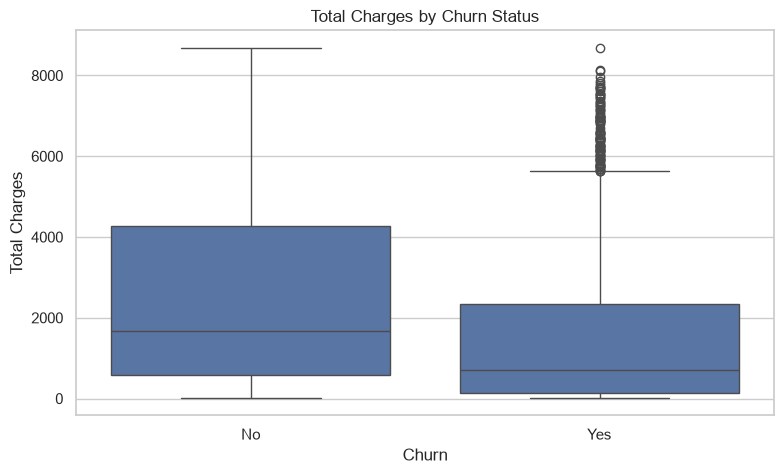

In [22]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="TotalCharges_numeric"
)

plt.title("Total Charges by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Total Charges")

plt.show()

### Important modelling note

`TotalCharges` is strongly related to `tenure` and `MonthlyCharges`.

That does not automatically make it a bad feature, but it means we should be careful about interpreting it as an independent business driver.

Later, feature engineering will consider relationships between these variables.

# Part C — Services and churn

Telecom customers can subscribe to multiple services.

Instead of generating a chart for every service without context, we will answer one useful question:

> **Which service categories show meaningful differences in churn rate?**

## 10. Internet service and churn

`InternetService` is a high-level service category and is a natural starting point.

In [23]:
internet_service_summary = (
    df.groupby("InternetService")["Churn"]
    .agg(
        Customers="count",
        Churned=lambda values: (values == "Yes").sum()
    )
)

internet_service_summary["Churn_Rate"] = (
    internet_service_summary["Churned"]
    / internet_service_summary["Customers"]
    * 100
).round(2)

internet_service_summary.sort_values(
    "Churn_Rate",
    ascending=False
)

,Customers,Churned,Churn_Rate
InternetService,,,
Fiber optic,3096,1297,41.89
DSL,2421,459,18.96
No,1526,113,7.40


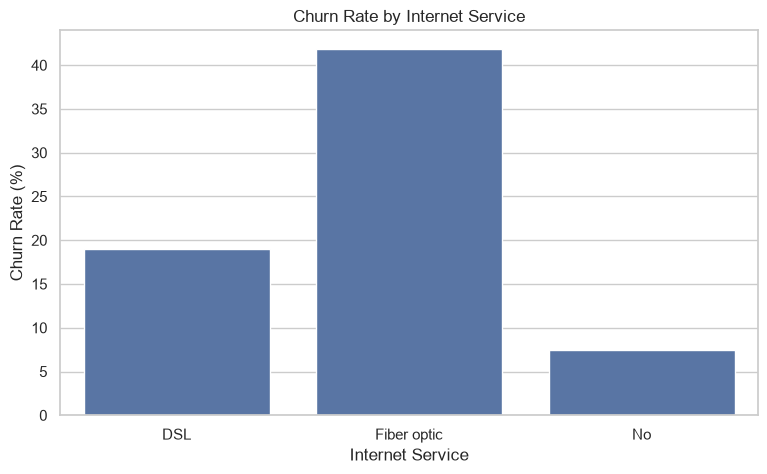

In [24]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=internet_service_summary.reset_index(),
    x="InternetService",
    y="Churn_Rate"
)

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")

plt.show()

### Interpretation

A meaningful difference here would tell us that the type of internet service is associated with different churn behaviour.

However, this could also reflect differences in pricing, contract type, service quality, or customer profiles. We will avoid treating one variable as the complete explanation.

## 11. Support-related services and churn

Customer support can be relevant to retention.

We will compare churn rates across:

- OnlineSecurity
- TechSupport
- DeviceProtection

In [25]:
support_service_columns = [
    "OnlineSecurity",
    "TechSupport",
    "DeviceProtection"
]

support_churn_results = []

for column in support_service_columns:

    churn_rate_by_value = (
        df.groupby(column)["Churn"]
        .apply(lambda values: (values == "Yes").mean() * 100)
        .round(2)
    )

    for category, churn_rate in churn_rate_by_value.items():
        support_churn_results.append({
            "Service": column,
            "Category": category,
            "Churn_Rate": churn_rate
        })

support_churn_summary = pd.DataFrame(support_churn_results)

support_churn_summary

,Service,Category,Churn_Rate
0,OnlineSecurity,No,41.77
1,OnlineSecurity,No internet service,7.40
2,OnlineSecurity,Yes,14.61
3,TechSupport,No,41.64
4,TechSupport,No internet service,7.40
5,TechSupport,Yes,15.17
6,DeviceProtection,No,39.13
7,DeviceProtection,No internet service,7.40
8,DeviceProtection,Yes,22.50


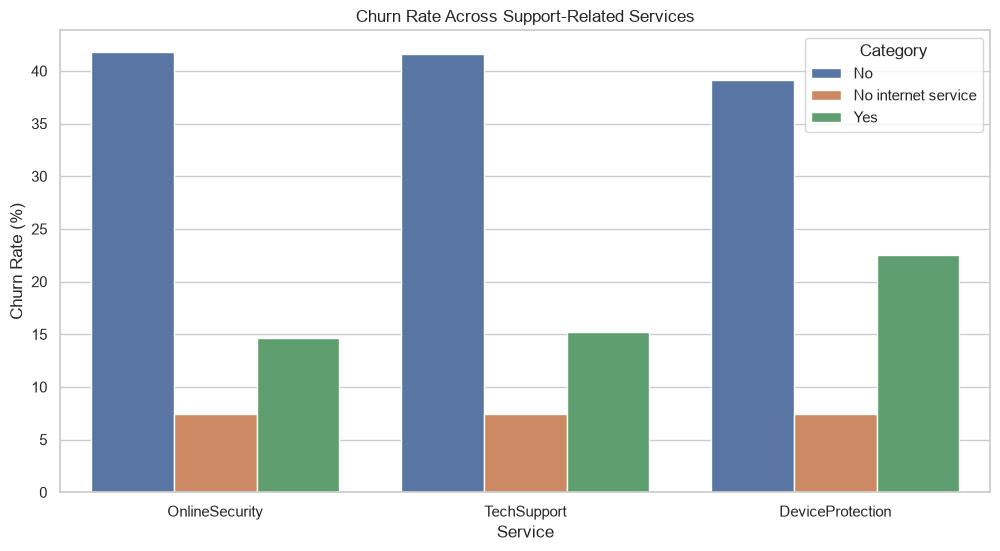

In [26]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=support_churn_summary,
    x="Service",
    y="Churn_Rate",
    hue="Category"
)

plt.title("Churn Rate Across Support-Related Services")
plt.xlabel("Service")
plt.ylabel("Churn Rate (%)")

plt.show()

### Interpretation

If customers without certain support services show consistently higher churn, these services may be useful predictive features.

The result can also create a business hypothesis:

> Customers with weaker service support may be more vulnerable to churn.

We will test whether this signal remains useful after considering other customer characteristics.

# Part D — Payment behaviour

## 12. Payment method and churn

### Business question

> Does payment method show a meaningful relationship with churn?

Payment method can sometimes act as a proxy for customer behaviour or friction in the billing experience.

In [27]:
payment_summary = (
    df.groupby("PaymentMethod")["Churn"]
    .agg(
        Customers="count",
        Churned=lambda values: (values == "Yes").sum()
    )
)

payment_summary["Churn_Rate"] = (
    payment_summary["Churned"]
    / payment_summary["Customers"]
    * 100
).round(2)

payment_summary.sort_values(
    "Churn_Rate",
    ascending=False
)

,Customers,Churned,Churn_Rate
PaymentMethod,,,
Electronic check,2365,1071,45.29
Mailed check,1612,308,19.11
Bank transfer (automatic),1544,258,16.71
Credit card (automatic),1522,232,15.24


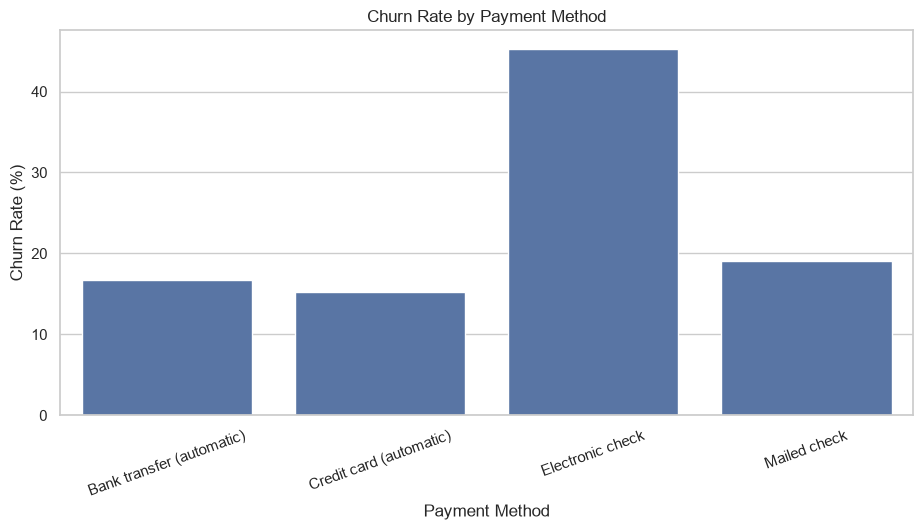

In [28]:
plt.figure(figsize=(11, 5))

sns.barplot(
    data=payment_summary.reset_index(),
    x="PaymentMethod",
    y="Churn_Rate"
)

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=20)

plt.show()

### Interpretation

Large differences between payment methods are worth carrying into feature engineering.

However, payment method itself may not be the root cause. It can be associated with customer tenure, contract type, or other behavioural differences.

# Part E — Demographics

Demographic variables should be explored, but we should avoid automatically assuming that every demographic difference is useful for prediction or business action.

## 13. Gender and churn

We check whether churn rates differ meaningfully between genders.

In [29]:
gender_summary = (
    df.groupby("gender")["Churn"]
    .apply(lambda values: (values == "Yes").mean() * 100)
    .round(2)
    .to_frame("Churn_Rate")
)

gender_summary

,Churn_Rate
gender,
Female,26.92
Male,26.16


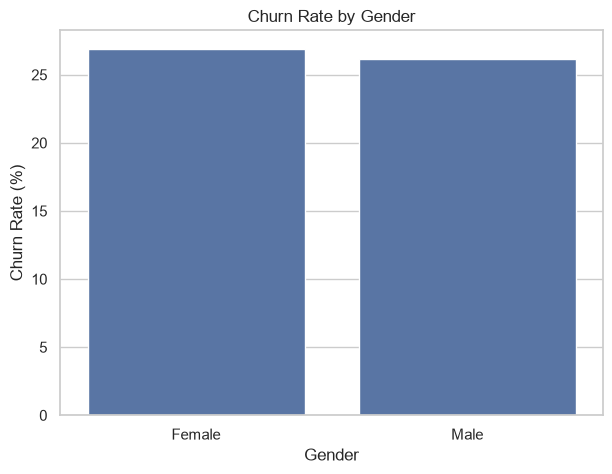

In [30]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=gender_summary.reset_index(),
    x="gender",
    y="Churn_Rate"
)

plt.title("Churn Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Churn Rate (%)")

plt.show()

### Interpretation

If the difference is small, gender is unlikely to be a major standalone churn signal.

We should let the evidence determine whether this variable deserves attention later rather than assuming that every demographic variable is important.

## 14. Partner and dependents

These variables provide additional context about the customer's household situation.

We compare churn rates rather than raw counts.

In [31]:
household_columns = [
    "Partner",
    "Dependents"
]

household_results = []

for column in household_columns:

    churn_rate_by_value = (
        df.groupby(column)["Churn"]
        .apply(lambda values: (values == "Yes").mean() * 100)
        .round(2)
    )

    for category, churn_rate in churn_rate_by_value.items():
        household_results.append({
            "Variable": column,
            "Category": category,
            "Churn_Rate": churn_rate
        })

household_summary = pd.DataFrame(household_results)

household_summary

,Variable,Category,Churn_Rate
0,Partner,No,32.96
1,Partner,Yes,19.66
2,Dependents,No,31.28
3,Dependents,Yes,15.45


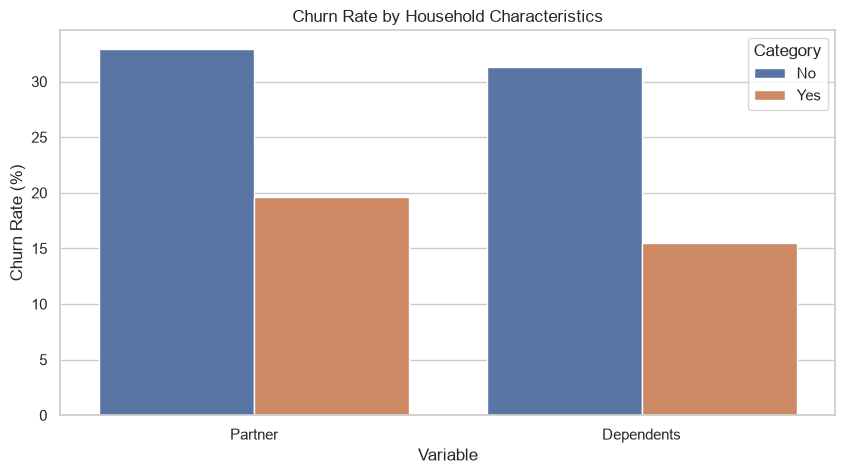

In [32]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=household_summary,
    x="Variable",
    y="Churn_Rate",
    hue="Category"
)

plt.title("Churn Rate by Household Characteristics")
plt.xlabel("Variable")
plt.ylabel("Churn Rate (%)")

plt.show()

## 15. Senior citizen status

This variable is already represented as `0` and `1` in the dataset.

For business readability, we create labels only for this analysis.

In [33]:
senior_citizen_labels = {
    0: "Non-Senior",
    1: "Senior"
}

df["SeniorCitizenLabel"] = df["SeniorCitizen"].map(
    senior_citizen_labels
)

senior_churn_summary = (
    df.groupby("SeniorCitizenLabel")["Churn"]
    .apply(lambda values: (values == "Yes").mean() * 100)
    .round(2)
    .to_frame("Churn_Rate")
)

senior_churn_summary

,Churn_Rate
SeniorCitizenLabel,
Non-Senior,23.61
Senior,41.68


# Part F — Combined business view

Individual variables can be useful, but churn behaviour is usually not driven by one variable in isolation.

We now look at a few combinations that have direct business meaning.

## 16. Contract type + tenure

### Business question

> Does the relationship between contract type and churn look different for newer versus established customers?

This is more useful than simply looking at contract and tenure separately because the business may want to target specific customer groups.

In [34]:
contract_tenure_summary = (
    df.groupby(["Contract", "TenureGroup"], observed=False)["Churn"]
    .apply(lambda values: (values == "Yes").mean() * 100)
    .reset_index(name="Churn_Rate")
)

contract_tenure_summary.head(20)

,Contract,TenureGroup,Churn_Rate
0,Month-to-month,0-6 months,55.201699
1,Month-to-month,7-12 months,41.996558
2,Month-to-month,13-24 months,37.720488
3,Month-to-month,25-48 months,32.917706
4,Month-to-month,49+ months,26.023392
5,One year,0-6 months,10.256410
6,One year,7-12 months,10.588235
7,One year,13-24 months,8.121827
8,One year,25-48 months,10.617761
9,One year,49+ months,12.933754


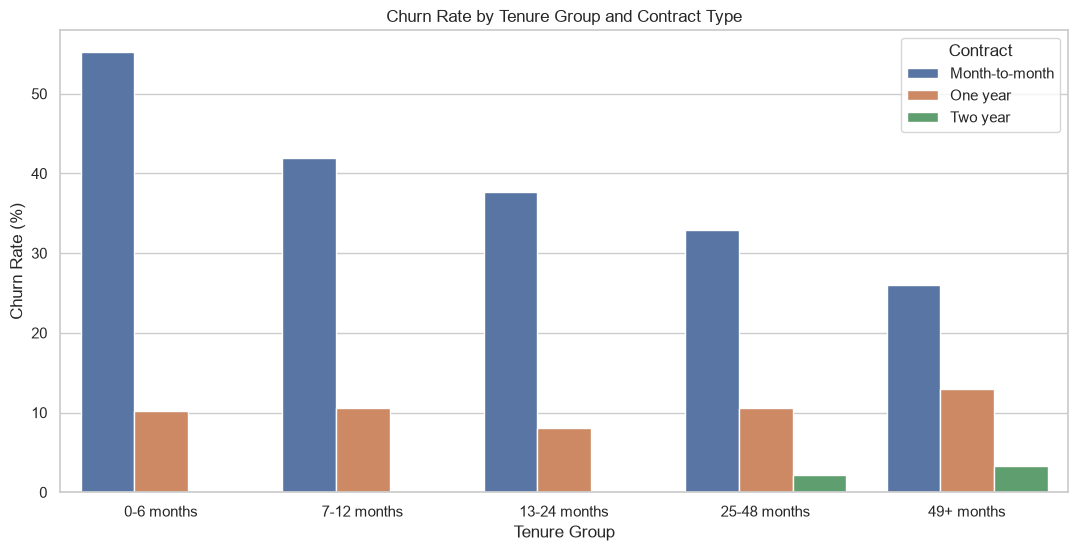

In [35]:
plt.figure(figsize=(13, 6))

sns.barplot(
    data=contract_tenure_summary,
    x="TenureGroup",
    y="Churn_Rate",
    hue="Contract"
)

plt.title("Churn Rate by Tenure Group and Contract Type")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")

plt.show()

### Why this matters

A pattern here can help us identify a more specific retention segment, such as:

> newer month-to-month customers

rather than treating all churn-risk customers as one homogeneous group.

## 17. Contract type + monthly charges

Another useful business question is whether the relationship between contract commitment and churn changes at different charge levels.

In [36]:
charge_contract_summary = (
    df.groupby(["Contract", "MonthlyChargeGroup"], observed=False)["Churn"]
    .apply(lambda values: (values == "Yes").mean() * 100)
    .reset_index(name="Churn_Rate")
)

charge_contract_summary.head(20)

,Contract,MonthlyChargeGroup,Churn_Rate
0,Month-to-month,≤ 30,22.897196
1,Month-to-month,31-60,35.722679
2,Month-to-month,61-90,49.639817
3,Month-to-month,91-120,52.163743
4,Month-to-month,120+,NaN
5,One year,≤ 30,2.688172
6,One year,31-60,7.569721
7,One year,61-90,10.891089
8,One year,91-120,20.852018
9,One year,120+,NaN


We will not over-interpret this table if the groups become too small. Later, model-based analysis will help us understand whether these variables provide independent predictive value.

# Part G — EDA conclusions

## 18. Create a concise business findings table

The purpose of this table is to capture what we learned from the analysis.

The exact numbers will be populated from the results above rather than being manually typed into the notebook.

In [37]:
# Collect the main churn-rate summaries into one place.

eda_findings = {
    "Overall churn rate": (
        df["Churn"].eq("Yes").mean() * 100
    ),
    "Highest-risk contract type": (
        contract_summary["Churn_Rate"].idxmax()
    ),
    "Highest-risk internet service": (
        internet_service_summary["Churn_Rate"].idxmax()
    ),
    "Highest-risk payment method": (
        payment_summary["Churn_Rate"].idxmax()
    )
}

eda_findings

{'Overall churn rate': np.float64(26.536987079369588),
 'Highest-risk contract type': 'Month-to-month',
 'Highest-risk internet service': 'Fiber optic',
 'Highest-risk payment method': 'Electronic check'}

## 19. What we learned

The most important outcome of EDA is not the charts themselves. It is the set of evidence-backed hypotheses that can influence the next stage.

### Questions to carry forward

Based on the results above, we should carry forward the variables that show meaningful and plausible relationships with churn, such as:

- tenure
- contract type
- monthly charges
- internet service
- support/service features
- payment method
- relevant household characteristics

We will not automatically keep every variable just because it appeared in EDA.

### What EDA does NOT prove

EDA shows **association**, not causation.

For example:

> If month-to-month customers churn more, we cannot conclude that changing the contract alone will prevent churn.

Other variables may explain part of the relationship.

### Next stage

The next notebook will focus on:

**03 — Data Cleaning & Feature Engineering**

There we will:

1. Clean `TotalCharges`.
2. Decide how to handle the identifier.
3. Convert categorical information into model-ready features.
4. Create useful business features where justified.
5. Avoid leakage.
6. Keep the transformation process reproducible.

> **The goal of feature engineering is not to create as many features as possible. It is to create useful, defensible representations of customer behaviour.**